# Imports

In [5]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_ntp_novelty_summary(
    results_dir,
    panel="error",               # "error", "map", or "geometry"
    layers=None,                 # None = all blocks; or (1, 4, 8)
    position="mean",             # "mean" or target-token position, starting at 2
    figsize=(7, 4.5),
    save_path=None,
):
    """One standalone figure using existing novelty-predictor diagnostics."""
    if panel not in {"error", "map", "geometry"}:
        raise ValueError("panel must be 'error', 'map', or 'geometry'")

    path = Path(results_dir).expanduser()
    if path.suffix != ".npz":
        path /= "novelty_overlaps.npz"

    required = {
        "error": ("novelty_residual_mse", "novelty_target_energy"),
        "map": ("novelty_map_relative_change",),
        "geometry": (
            "novelty_prediction_cka",
            "novelty_prediction_change",
            "novelty_reference_target_energy",
        ),
    }[panel]

    with np.load(path, allow_pickle=True) as f:
        missing = [k for k in required if k not in f.files]
        if missing:
            raise ValueError(f"Missing predictor diagnostics: {missing}")
        names = f["layer_names"].tolist()
        times = np.asarray(f["selected_steps"])
        ref_index = int(f["novelty_dynamics_reference_index"])
        data = {k: np.asarray(f[k], dtype=float) for k in required}

    def block_number(name):
        return int(str(name).rsplit("_", 1)[-1])

    available = {block_number(name): i for i, name in enumerate(names)}
    selected = (
        sorted(available)
        if layers is None
        else [block_number(x) for x in layers]
    )
    if not selected or any(n not in available for n in selected):
        raise ValueError(f"Choose layers from {sorted(available)}")

    # Color depends on block identity, not on the selected subset.
    all_blocks = sorted(available)
    colors = dict(zip(
        all_blocks,
        plt.get_cmap("turbo")(np.linspace(0.05, 0.95, len(all_blocks))),
    ))
    order = np.argsort(times)
    reference_time = times[ref_index]

    if panel != "map":
        n_positions = data[required[0]].shape[-1]
        positions = np.arange(2, n_positions + 2)
        pi = (
            np.arange(n_positions)
            if position == "mean"
            else np.flatnonzero(positions == int(position))
        )
        if len(pi) == 0:
            raise ValueError(f"Available target positions: {positions.tolist()}")

    def pooled(key, layer_index):
        # Equal-weight positions. Undefined CKA remains undefined.
        return data[key][:, layer_index, :][:, pi].mean(axis=-1)

    def divide(num, den):
        return np.divide(
            num, den,
            out=np.full_like(num, np.nan),
            where=den > 1e-20,
        )

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    for number in selected:
        i = available[number]
        color = colors[number]
        label = f"Block {number}"

        if panel == "error":
            y = divide(
                pooled("novelty_residual_mse", i),
                pooled("novelty_target_energy", i),
            )
            ax.plot(times[order], y[order], color=color, lw=2, label=label)

        elif panel == "map":
            y = data["novelty_map_relative_change"][:, i]
            ax.plot(times[order], y[order], color=color, lw=2, label=label)

        else:
            q = pooled("novelty_prediction_cka", i)
            d = divide(
                pooled("novelty_prediction_change", i),
                pooled("novelty_reference_target_energy", i),
            )
            # RMS difference relative to the reference target's fluctuation scale.
            rms = np.sqrt(np.maximum(d, 0))
            ax.plot(
                q[order], rms[order],
                color=color, lw=1.7, marker=".", ms=5, label=label,
            )
            first = order[0]
            if np.isfinite(q[first]) and np.isfinite(rms[first]):
                ax.scatter(
                    q[first], rms[first],
                    s=65, color=color, edgecolor="black",
                    linewidth=0.6, zorder=4,
                )

    ax.grid(alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

    if panel == "error":
        ax.set_title("How well does the linear predictor reconstruct the block?")
        ax.set_ylabel("Residual MSE / target variance")
        ax.set_ylim(bottom=0)

    elif panel == "map":
        ax.set_title(f"How far is the predictor from its final map?  (t*={reference_time:g})")
        ax.set_ylabel(r"$\|A_t-A_*\|_F^2\,/\,\|A_*\|_F^2$")
        ax.set_ylim(bottom=0)

    else:
        ax.set_title("Similar geometry does not imply similar predictions")
        ax.set_xlabel("Prediction CKA with final checkpoint")
        ax.set_ylabel("Prediction RMS difference / reference target RMS")
        ax.set_xlim(-0.02, 1.03)
        ax.set_ylim(bottom=-0.03)
        ax.scatter([1], [0], marker="x", color="black", s=65, zorder=5)
        handles, labels = ax.get_legend_handles_labels()
        handles += [
            Line2D([], [], marker="o", color="black", linestyle="None",
                   markerfacecolor="white", label=f"Start: t={times[order[0]]:g}"),
            Line2D([], [], marker="x", color="black", linestyle="None",
                   label=f"Reference: t={reference_time:g}"),
        ]
        ax.legend(handles=handles, fontsize=9, ncol=2)

    if panel != "geometry":
        ax.set_xscale("log" if np.all(times > 0) else "symlog")
        ax.set_xlabel("Training step")
        ax.legend(fontsize=9, ncol=2)

    if save_path is not None:
        out = Path(save_path).expanduser()
        out.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out, dpi=200, bbox_inches="tight")

    return fig, ax

results = (
    "/mnt/beegfs/2a/mb12724/franc/small-language-modelling/"
    "collected_results/L4_novelty_dynamics_v1"
)

# Dynamics of linear probe of each layer

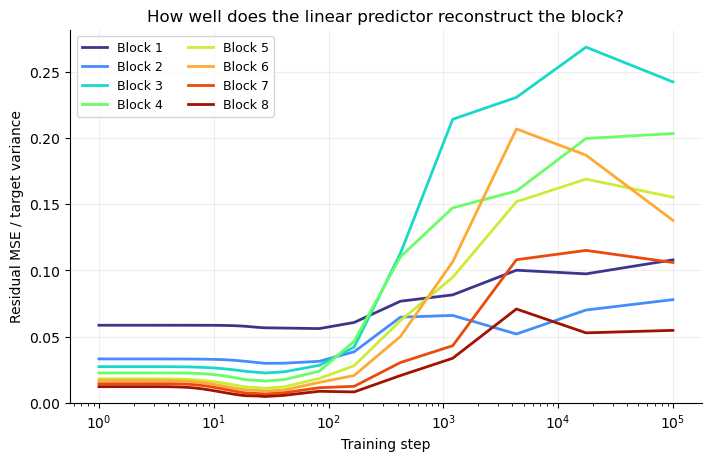

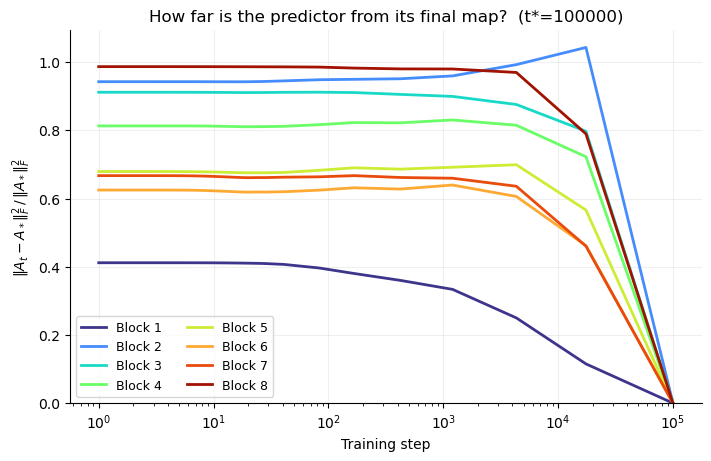

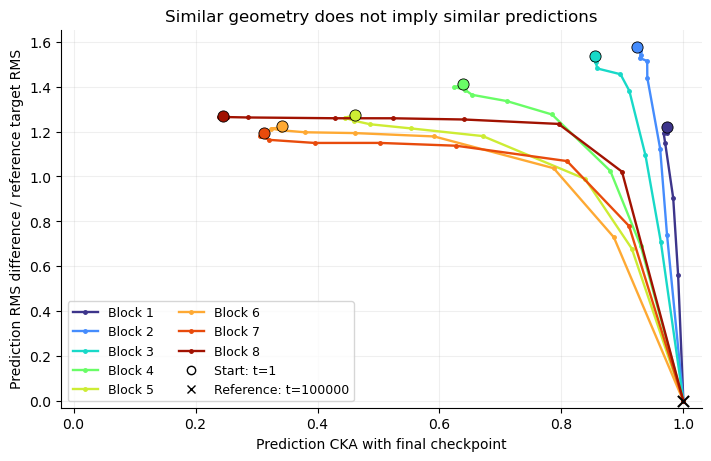

In [6]:
fig_error, ax_error = plot_ntp_novelty_summary(
    results, panel="error",
    save_path=f"{results}/novelty_reconstruction.png",
)

fig_map, ax_map = plot_ntp_novelty_summary(
    results, panel="map",
    save_path=f"{results}/novelty_map_drift.png",
)

fig_geometry, ax_geometry = plot_ntp_novelty_summary(
    results, panel="geometry",
    save_path=f"{results}/novelty_geometry_vs_drift.png",
)